# Laboratorio 5 — Clasificación de tweets usando minería de texto

## Parte 1: Análisis exploratorio y análisis de sentimiento

**CC3084 – Data Science · Universidad del Valle de Guatemala · Semestre II 2026**

**Dataset:** [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started) (Kaggle)

---
# 0. Configuración y descarga de datos

In [1]:
import os, re, string, warnings, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("data")
FIG_DIR  = Path("figuras")     # aquí se guardan las gráficas para pegarlas en el informe
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

def guardar_fig(nombre):
    # Guarda la figura actual en figuras/ para poder referenciarla en el informe PDF
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")

print("Entorno listo")

Entorno listo


## 0.1 Descarga del `train.csv`

`nlp-getting-started` es una **competencia** de Kaggle, no un dataset público, así que la descarga automática pide credenciales y que hayan aceptado las reglas de la competencia. Pasos, una sola vez:

1. Entrar a <https://www.kaggle.com/c/nlp-getting-started> con su cuenta y darle a **Join Competition** (si no aceptan las reglas, la API responde 403).
2. En Kaggle: *Settings → API → Create New Token*. Se descarga `kaggle.json`.
3. Colocarlo en `~/.kaggle/kaggle.json` (Linux/Mac) o `C:\Users\<usuario>\.kaggle\kaggle.json` (Windows). En Linux/Mac además: `chmod 600 ~/.kaggle/kaggle.json`.
   - **En Google Colab** es más fácil: suban el `kaggle.json` con el widget de archivos y corran la celda, que ya lo mueve sola.

La celda de abajo intenta, en orden: (a) usar el archivo si ya está en `data/`, (b) `kagglehub`, (c) la CLI de `kaggle`. Si las tres fallan les dice qué hacer y basta con arrastrar el `train.csv` a la carpeta `data/`.

In [2]:
# --- Colab: descomentar estas 3 líneas si van a subir el kaggle.json a mano ---
# from google.colab import files; files.upload()
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

def obtener_datos(destino=DATA_DIR / "train.csv"):
    destino = Path(destino)
    if destino.exists():
        print(f"OK: ya existe {destino}")
        return destino

    # Opción A: kagglehub
    try:
        import kagglehub, shutil
        ruta = kagglehub.competition_download("nlp-getting-started")
        for f in Path(ruta).rglob("train.csv"):
            shutil.copy(f, destino)
            print(f"OK: descargado con kagglehub -> {destino}")
            return destino
    except Exception as e:
        print(f"kagglehub no funcionó ({type(e).__name__}: {e})")

    # Opción B: CLI de kaggle
    try:
        import subprocess, zipfile
        subprocess.run(
            ["kaggle", "competitions", "download", "-c", "nlp-getting-started",
             "-p", str(DATA_DIR)], check=True)
        zip_path = DATA_DIR / "nlp-getting-started.zip"
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)
        print(f"OK: descargado con la CLI de kaggle -> {destino}")
        return destino
    except Exception as e:
        print(f"CLI de kaggle no funcionó ({type(e).__name__}: {e})")

    raise FileNotFoundError(
        "No se pudo descargar automáticamente.\n"
        "Plan B (30 segundos): bajen train.csv de\n"
        "  https://www.kaggle.com/c/nlp-getting-started/data\n"
        f"y déjenlo en: {destino.resolve()}"
    )

ruta_train = obtener_datos()

OK: ya existe data\train.csv


In [3]:
df = pd.read_csv(ruta_train)
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()

Filas: 7613  |  Columnas: 5


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


> **Nota sobre el tamaño del dataset.** El enunciado dice "más de 10 500 filas", pero el `train.csv`
> de esa competencia trae 7 613. Las 10 876 salen de sumar `train.csv` + `test.csv` (3 263).
> Como `test.csv` **no tiene la columna `target`**, no sirve para entrenar ni evaluar: todo el
> laboratorio se hace sobre `train.csv` y de ahí se separa el conjunto de prueba. Vale la pena
> mencionarlo en el informe, es el tipo de detalle que se agradece.

---
# 1. Análisis exploratorio

*Punto 5 del enunciado (15 pts). Objetivo: entender los datos y documentar cruces de variables.*

Recordatorio: la nota no se la dan las gráficas sino lo que **escriban debajo** de cada una. Cada celda tiene un espacio de análisis; llénenlo con lo que efectivamente observaron.

In [4]:
# 1.1 Estructura general y valores faltantes
print(df.info())
print("\nDuplicados exactos de texto:", df.duplicated(subset=["text"]).sum())

faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(2)
})
faltantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None

Duplicados exactos de texto: 110


,n_faltantes,pct_faltantes
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


target
0    4342
1    3271
Name: count, dtype: int64

Proporciones:
 target
0    0.5703
1    0.4297
Name: count, dtype: float64


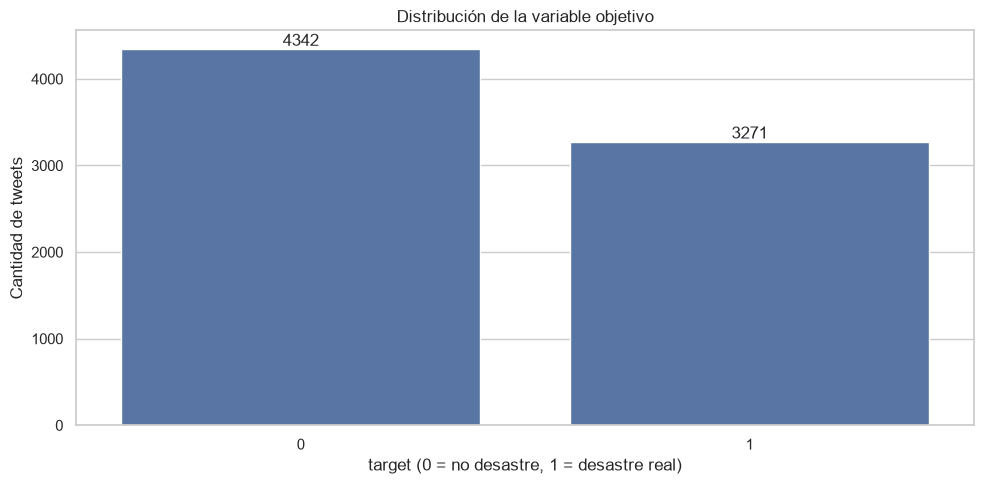

In [5]:
# 1.2 Distribución de la variable objetivo
conteo = df["target"].value_counts().sort_index()
print(conteo)
print("\nProporciones:\n", (conteo / len(df)).round(4))

ax = sns.countplot(data=df, x="target")
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("target (0 = no desastre, 1 = desastre real)")
ax.set_ylabel("Cantidad de tweets")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
guardar_fig("01_distribucion_target")
plt.show()

**Análisis 1.2:** ¿está balanceado el dataset? Si la clase 0 es ~57% y la 1 ~43%, el desbalance es leve — un modelo que prediga siempre "no desastre" acertaría ese 57%, y ese es el **baseline** contra el que hay que comparar en la sección de modelos. Escriban aquí la conclusión.

In [6]:
# 1.3 Duplicados con etiquetas contradictorias (mismo texto, distinto target)
contradictorios = (df.groupby("text")["target"]
                    .agg(["nunique", "count", "mean"])
                    .query("nunique > 1")
                    .sort_values("count", ascending=False))
print(f"Textos repetidos con etiqueta contradictoria: {len(contradictorios)}")
contradictorios.head(10)

Textos repetidos con etiqueta contradictoria: 18


,nunique,count,mean
text,,,
The Prophet (peace be upon him) said 'Save yourself from Hellfire even if it is by giving half a date in charity.',2,6,0.333333
He came to a land which was engulfed in tribal war and turned it into a land of peace i.e. Madinah. #ProphetMuhammad #islam,2,6,0.333333
that horrible sinking feeling when youÛªve been at home on your phone for a while and you realise its been on 3G this whole time,2,4,0.500000
.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https://t.co/rqWuoy1fm4,2,4,0.750000
To fight bioterrorism sir.,2,4,0.500000
#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,2,3,0.333333
#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,2,3,0.666667
Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her\n \n#FARRAKHAN #QUOTE,2,3,0.333333
CLEARED:incident with injury:I-495 inner loop Exit 31 - MD 97/Georgia Ave Silver Spring,2,3,0.666667


**Análisis 1.3:** estos casos son ruido de etiquetado del dataset original. Comenten cuántos son y si vale la pena eliminarlos (son pocos, pero ponen un techo al accuracy alcanzable).

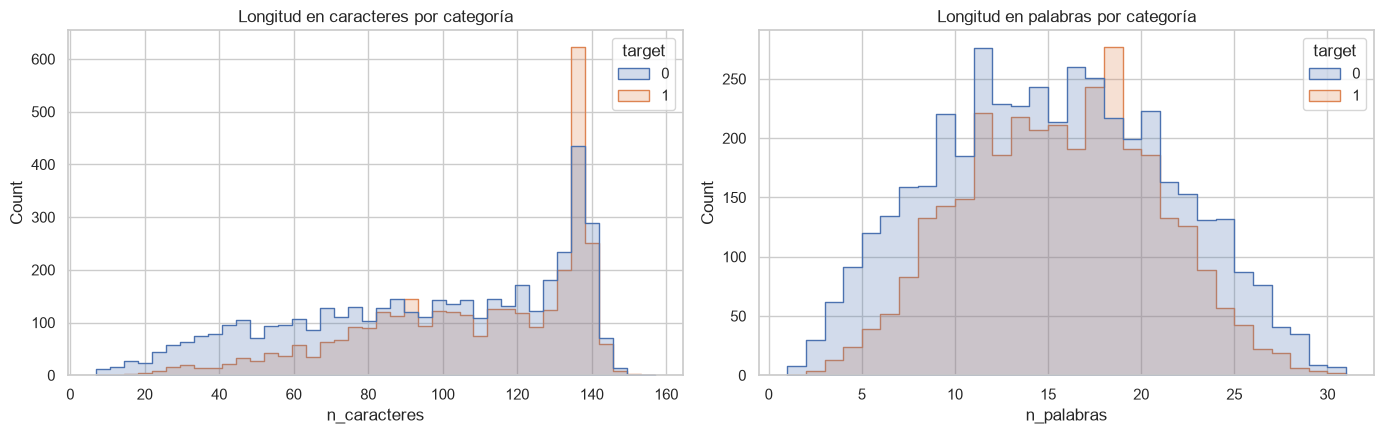

target                        0            1
n_caracteres count  4342.000000  3271.000000
             mean     95.706817   108.113421
             std      35.885924    29.309854
             min       7.000000    14.000000
             25%      68.000000    88.000000
             50%     101.000000   115.000000
             75%     130.000000   136.000000
             max     157.000000   151.000000
n_palabras   count  4342.000000  3271.000000
             mean     14.704744    15.167533
             std       6.161564     5.096806
             min       1.000000     2.000000
             25%      10.000000    11.000000
             50%      15.000000    15.000000
             75%      19.000000    19.000000
             max      31.000000    30.000000

In [7]:
# 1.4 Longitud de los tweets: caracteres y palabras
df["n_caracteres"] = df["text"].str.len()
df["n_palabras"]   = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=df, x="n_caracteres", hue="target", bins=40, ax=axes[0], element="step")
axes[0].set_title("Longitud en caracteres por categoría")
sns.histplot(data=df, x="n_palabras", hue="target", bins=30, ax=axes[1], element="step")
axes[1].set_title("Longitud en palabras por categoría")
guardar_fig("02_longitudes")
plt.show()

df.groupby("target")[["n_caracteres", "n_palabras"]].describe().T

**Análisis 1.4:** ¿los tweets de desastre real son más largos? Si la diferencia de medias es consistente, `n_palabras` puede servir como variable extra para el modelo — anótenlo como variable candidata para la sección de modelos.

target               0       1
tiene_url       0.4143  0.6640
n_menciones     0.4203  0.2721
n_hashtags      0.3888  0.5020
tiene_numero    0.4963  0.7245
menciona_911    0.0002  0.0009
pct_mayusculas  0.0980  0.1019


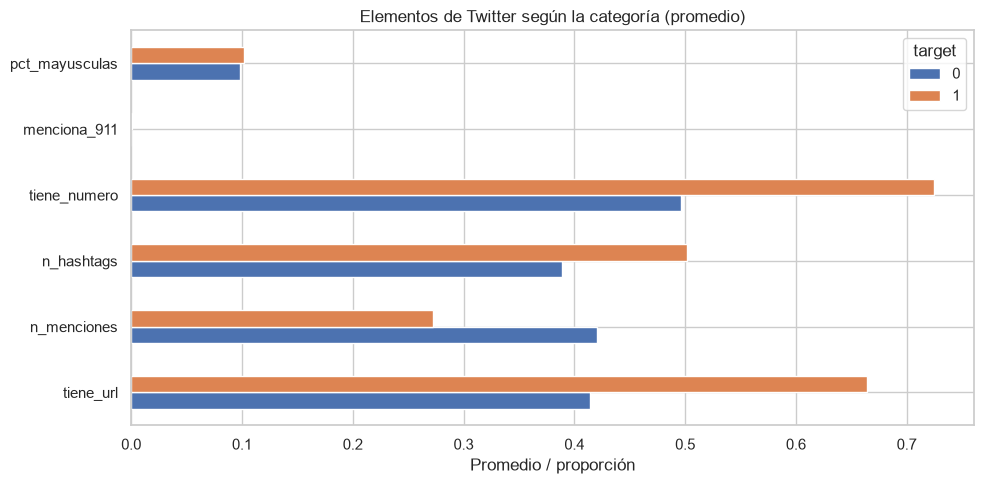

In [8]:
# 1.5 Elementos propios de Twitter: URLs, menciones, hashtags, números, mayúsculas
df["tiene_url"]      = df["text"].str.contains(r"http\S+", regex=True).astype(int)
df["n_menciones"]    = df["text"].str.count(r"@\w+")
df["n_hashtags"]     = df["text"].str.count(r"#\w+")
df["tiene_numero"]   = df["text"].str.contains(r"\d", regex=True).astype(int)
df["menciona_911"]   = df["text"].str.contains(r"\b911\b", regex=True).astype(int)
df["pct_mayusculas"] = df["text"].apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1))

resumen = df.groupby("target")[["tiene_url", "n_menciones", "n_hashtags",
                                "tiene_numero", "menciona_911", "pct_mayusculas"]].mean().round(4)
print(resumen.T)

ax = resumen.T.plot(kind="barh")
ax.set_title("Elementos de Twitter según la categoría (promedio)")
ax.set_xlabel("Promedio / proporción")
ax.legend(title="target")
guardar_fig("03_elementos_twitter")
plt.show()

**Análisis 1.5:** este cruce es clave y conecta con el punto 3 del enunciado. Fíjense sobre todo en:

- **URLs**: si aparecen mucho más en la clase 1, es porque los tweets de desastre real suelen citar noticias. Eso justifica crear una variable `tiene_url` *antes* de borrar las URLs del texto.
- **911**: contar en cuántos tweets aparece y con qué proporción de desastre real. Ese dato es la justificación empírica para la pregunta del enunciado de si conservarlo o no.

Keywords distintas: 221
Tweets sin keyword: 61


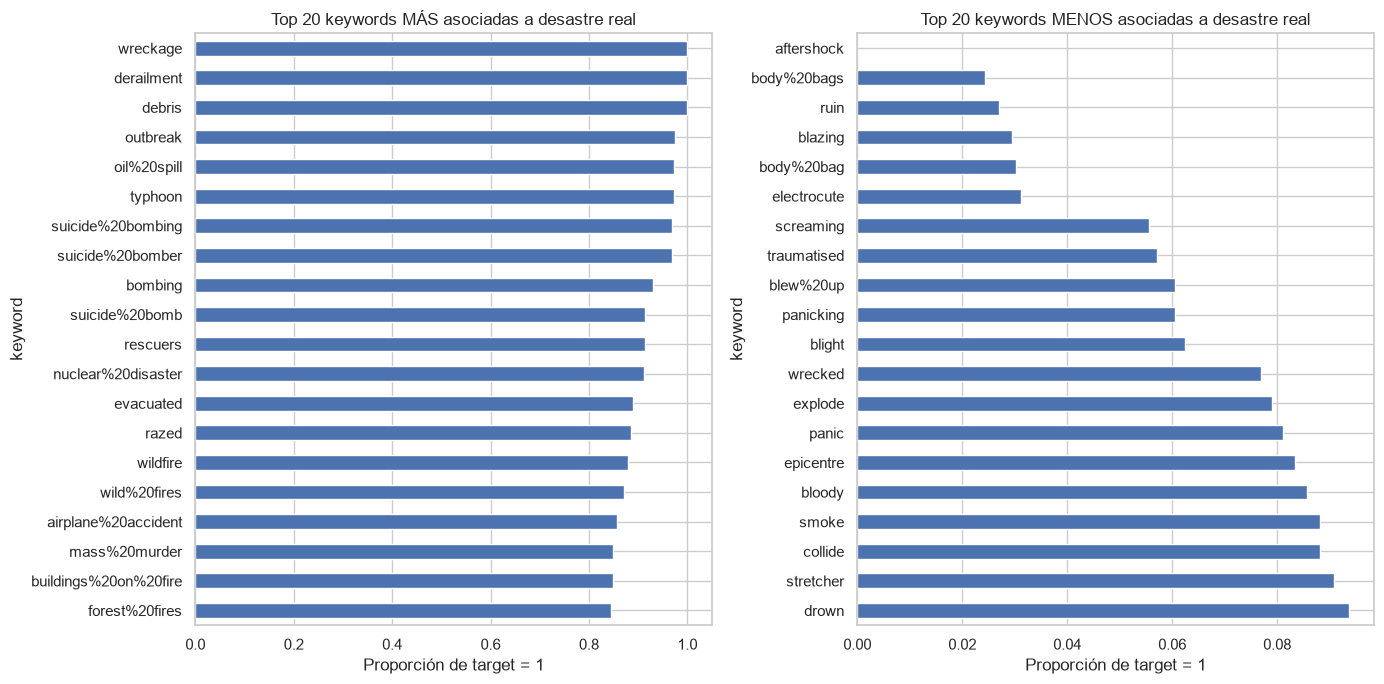

In [9]:
# 1.6 La variable keyword
print("Keywords distintas:", df["keyword"].nunique())
print("Tweets sin keyword:", df["keyword"].isna().sum())

kw = (df.dropna(subset=["keyword"])
        .groupby("keyword")["target"]
        .agg(["count", "mean"])
        .rename(columns={"count": "n_tweets", "mean": "prop_desastre"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
kw.nlargest(20, "prop_desastre").sort_values("prop_desastre").plot(
    kind="barh", y="prop_desastre", ax=axes[0], legend=False)
axes[0].set_title("Top 20 keywords MÁS asociadas a desastre real")
axes[0].set_xlabel("Proporción de target = 1")

kw.nsmallest(20, "prop_desastre").sort_values("prop_desastre", ascending=False).plot(
    kind="barh", y="prop_desastre", ax=axes[1], legend=False)
axes[1].set_title("Top 20 keywords MENOS asociadas a desastre real")
axes[1].set_xlabel("Proporción de target = 1")
guardar_fig("04_keywords_vs_target")
plt.show()

**Análisis 1.6:** este es el cruce de variables más rentable del laboratorio. Hay keywords casi deterministas (`debris`, `wreckage`, `derailment` suelen ser ~100% desastre) y otras que son puro lenguaje figurado (`aftershock`, `blazing`, `body bag` usadas como metáfora). Discutan:

1. ¿Sirve `keyword` como variable predictora aparte del texto? (Spoiler: sí, mucho; se prueba el modelo con y sin ella en la sección de modelos.)
2. ¿Qué keywords son ambiguas — cerca de 0.5? Esas son justamente los tweets donde el modelo se va a equivocar, y explican bastante del error final.

Locations distintas: 3341
Tweets sin location: 2533 (33.3%)


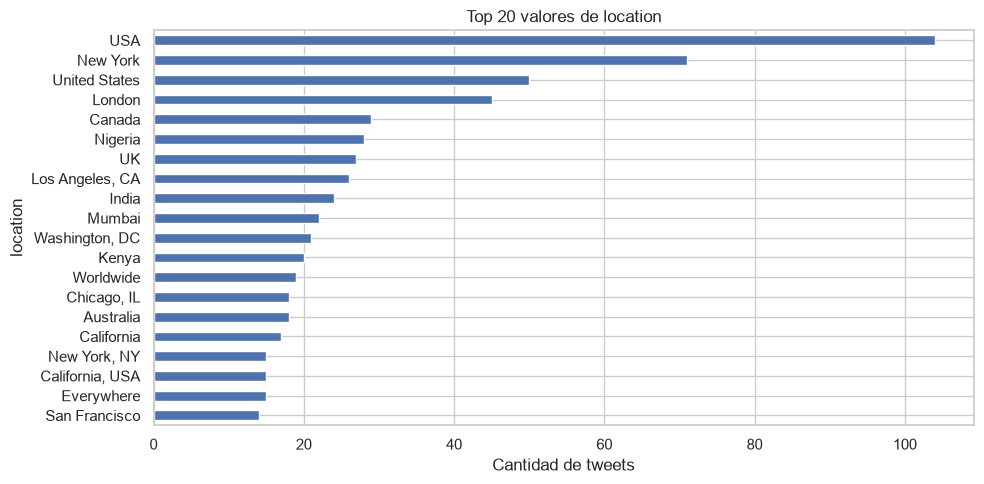

,count,prop_desastre
location,,
Mumbai,22,0.863636
India,24,0.833333
Nigeria,28,0.785714
"Washington, DC",21,0.714286
USA,104,0.644231
Worldwide,19,0.631579
UK,27,0.592593
United States,50,0.540000
"California, USA",15,0.533333


In [10]:
# 1.7 La variable location
print("Locations distintas:", df["location"].nunique())
print("Tweets sin location:", df["location"].isna().sum(),
      f"({df['location'].isna().mean():.1%})")

top_loc = df["location"].value_counts().head(20)
ax = top_loc.sort_values().plot(kind="barh")
ax.set_title("Top 20 valores de location")
ax.set_xlabel("Cantidad de tweets")
guardar_fig("05_top_locations")
plt.show()

# Proporción de desastre en las locations más frecuentes
(df[df["location"].isin(top_loc.index)]
   .groupby("location")["target"].agg(["count", "mean"])
   .rename(columns={"mean": "prop_desastre"})
   .sort_values("prop_desastre", ascending=False))

**Análisis 1.7:** `location` es texto libre sin validar — van a encontrar cosas como "Worldwide", "Everywhere" o nombres inventados, además de un tercio de valores nulos. Argumenten si vale la pena usarla o descartarla; descartarla está bien **si lo justifican con evidencia** (porcentaje de nulos + cardinalidad + ejemplos de basura).

In [11]:
# 1.8 Guardar el dataset con las variables derivadas, para las demás secciones
df.to_csv(DATA_DIR / "train_eda.csv", index=False)
print("Guardado: data/train_eda.csv")

Guardado: data/train_eda.csv
